# R11-H108 - surface the attached propositions: the direct render fix

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R11 weak-flank round, retrieval family; also the top-gradient edit class for R10-H81 <br>
**Graph**: rebuilt CPAP graph (neo4j2), 28-probe gold set <br>

H61 found 6 of 33 golds (18%) living in propositions ATTACHED to rendered seed nodes but invisible
to the render - production only shows propositions the separate global channel retrieves. This
notebook tests the direct fix: render the top-M attached propositions per seed, ranked by
probe-embedding cosine, inside a fixed token budget.

Pre-registered bar: direct-render evidence recall 0.697 (23/33) -> >=0.85 at <=+10% tokens with
zero displacement of currently-present golds.

## Approach
1. **Baseline** - H61's render convention (base + alias merge + relations[:15]); tiktoken accounting
2. **Fix** - append top-M attached propositions per seed (cosine vs probe embedding), M in {1,2,3,5}
3. **Verdict** - recall, token delta, displacement check per M; bar reads at the chosen operating M

## Outputs
- `reports/probe-render-r11h108-<stamp>.json` - recall/token curves per M, verdict
- In-notebook: recall-vs-token-budget curve, recovered-gold listing

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env
import re  # evidence normalization

# third party
import numpy as np  # cosine ranking
import tiktoken  # token accounting
import yaml  # probe set
import matplotlib.pyplot as plt  # recall/token curve
from pathlib import Path
from rich import print as rprint  # semantic output
from rich.progress import Progress  # replay loop

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

# project
from knowledge_graph_foundry import Foundry, load_settings  # pipeline
from knowledge_graph_foundry.extraction import generate_embeddings  # Titan probe embedding
from knowledge_graph_foundry.graph.graphrag import vector_query  # seed channel
from knowledge_graph_foundry.models import Entity  # embedding probe wrapper

2026-07-06 22:40:41.512 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")

settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k            # production vector seeds (8)
VEC_INDEX = settings.graphrag.vector_index_name
REL_LIMIT = 15                             # production relation cap (H61: vindicated)
M_SWEEP = [1, 2, 3, 5]                     # attached propositions per seed

# pre-registered bar (experiments log, R11-H108)
BAR_RECALL = 0.85       # direct-render recall target (baseline 0.697)
BAR_TOKENS = 0.10       # max mean token increase
# displacement clause: zero previously-present golds lost

enc = tiktoken.get_encoding("cl100k_base")
probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold]
  Neo4j: [cyan]{os.environ['NEO4J_URI']}[/cyan]

[bold]Render fix[/bold]
  Seeds: vec [yellow]{TOP_K}[/yellow]  Rel cap: [yellow]{REL_LIMIT}[/yellow]  M sweep: [yellow]{M_SWEEP}[/yellow]

[bold]Acceptance bar[/bold]
  Recall >= [yellow]{BAR_RECALL}[/yellow] [dim](baseline 0.697)[/dim]  Tokens <= [yellow]+{BAR_TOKENS:.0%}[/yellow]  Displacement: [yellow]0[/yellow]
  Probes: [yellow]{len(gold_probes)}[/yellow] with gold evidence
""")

Configuration
────────────────────────────────────────
Graph
  Neo4j: bolt://user-konrad.jelen-kgf-neo4j2:7687

Render fix
  Seeds: vec 8  Rel cap: 15  M sweep: [1, 2, 3, 5]

Acceptance bar
  Recall >= 0.85 (baseline 0.697)  Tokens <= +10%  Displacement: 0
  Probes: 24 with gold evidence

## Harvest - baseline renders plus attached propositions with embeddings

Per probe: vec-8 seeds; per seed: H61's baseline render (name/types/description/props + alias
merge + relations[:15]) and ALL attached propositions with their stored embeddings for
probe-cosine ranking.

In [3]:
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())


def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)


_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"


def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6


BASE_CACHE, PROP_CACHE = {}, {}


def node_render(session, nid):
    if nid not in BASE_CACHE:
        row = session.run(
            "MATCH (e:Entity {id: $id}) RETURN e.name AS name, labels(e) AS types, "
            "e.description AS description, properties(e) AS props", id=nid).single()
        spec = {k.removeprefix("prop_"): v for k, v in row["props"].items() if k.startswith("prop_")}
        aliases = session.run(
            "MATCH (e:Entity {id: $id})-[:SAME_AS*1..2]-(a:Entity) WHERE a.id <> $id "
            "RETURN DISTINCT a.name AS name, properties(a) AS props LIMIT 5", id=nid).data()
        for a in aliases:
            for k, v in a["props"].items():
                if k.startswith("prop_"):
                    spec.setdefault(k.removeprefix("prop_"), v)
        rels = session.run(
            "MATCH (e:Entity {id: $id})-[r]-(n:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' "
            "RETURN type(r) AS rel, n.name AS name LIMIT 15", id=nid).data()
        BASE_CACHE[nid] = (
            f"## {row['name']} ({', '.join(row['types'])})\n"
            + (f"Also known as: {', '.join(a['name'] for a in aliases)}\n" if aliases else "")
            + f"{row['description'] or ''}\nProperties: {json.dumps(spec, default=str)}\n"
            + "Relations: " + "; ".join(f"{r['rel']} -> {r['name']}" for r in rels)
        )
        PROP_CACHE[nid] = session.run(
            "MATCH (p:Proposition)-[:ABOUT]->(e:Entity {id: $id}) "
            "RETURN p.text AS text, p.embedding AS emb", id=nid).data()
    return BASE_CACHE[nid], PROP_CACHE[nid]


harvest = {}
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("harvest", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        emb = np.array(generate_embeddings([probe_e], settings.embeddings)[0].embedding)
        emb = emb / np.linalg.norm(emb)
        seed_ids = [s_["id"] for s_ in vector_query(f.driver, emb.tolist(), VEC_INDEX, top_k=TOP_K)]
        with f.driver.session() as session:
            nodes = {nid: node_render(session, nid) for nid in seed_ids}
        ranked_props = {}
        for nid, (_, props_) in nodes.items():
            scored = []
            for pr in props_:
                if pr["emb"]:
                    v = np.array(pr["emb"]); v = v / np.linalg.norm(v)
                    scored.append((float(v @ emb), pr["text"]))
            ranked_props[nid] = [t for _, t in sorted(scored, key=lambda x: -x[0])]
        harvest[p["id"]] = {"gold": p["gold_evidence"], "seeds": seed_ids, "ranked": ranked_props}
        progress.advance(task)

n_props_avail = sum(len(v) for h in harvest.values() for v in h["ranked"].values())
rprint(f"[green]harvested[/green] {len(harvest)} probes; attached propositions available: [yellow]{n_props_avail}[/yellow]")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-06 22:40:42.368 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 22:40:42.370 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name LIMIT 15"

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name LIMIT 15"

...

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name LIMIT 15"

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name LIMIT 15"

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name LIMIT 15"

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key
does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', 
position=<SummaryInputPosition line=1, column=51, offset=50>, raw_classification='UNRECOGNIZED', 
classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', 
severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', 
'_severity': 'WARNING', '_position': {'offset': 50, 'line': 1, 'column': 51}, 'OPERATION': '', 'OPERATION_CODE': 
'0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (e:Entity {id: $id})-[r]-(n:Entity) WHERE r.valid_to IS NULL AND 
type(r) <> 'SIMILAR_TO' RETURN type(r) AS rel, n.name AS name LIMIT 15"

harvested 24 probes; attached propositions available: 4330

## Replay sweep and verdict

Baseline = seed renders alone. Fix = baseline + top-M attached propositions per seed. Per M:
evidence recall, mean token delta, displacement count. The bar reads at the smallest M that
clears the recall target.

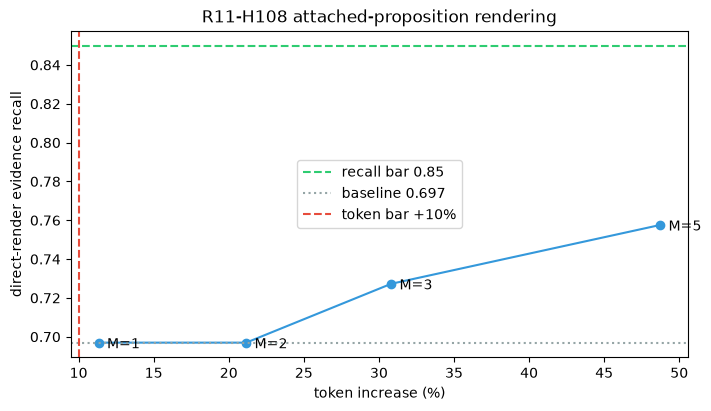

H108 render fix
────────────────────────────────────────
  Baseline recall: 0.697

M=1: recall 0.697  tokens +11.3%  lost 0

M=2: recall 0.697  tokens +21.2%  lost 0

M=3: recall 0.727  tokens +30.8%  lost 0

M=5: recall 0.758  tokens +48.7%  lost 0

Operating point: none clears bar  Verdict: PARTIAL

saved ../reports/probe-render-r11h108-20260706-204052.json

In [4]:
def eval_config(M):
    hits, total, tok_base, tok_fix, lost = 0, 0, 0, 0, []
    base_present = {}
    for pid, h in harvest.items():
        base_ctx = "\n".join(BASE_CACHE[nid] for nid in h["seeds"])
        fix_ctx = base_ctx + "\n" + "\n".join(
            f"Fact: {t}" for nid in h["seeds"] for t in h["ranked"][nid][:M])
        nb_, nf_ = _norm(base_ctx), _norm(fix_ctx)
        tok_base += len(enc.encode(base_ctx)); tok_fix += len(enc.encode(fix_ctx))
        for g in h["gold"]:
            total += 1
            b, x = present(g, nb_), present(g, nf_)
            hits += int(x)
            base_present[(pid, g)] = b
            if b and not x:
                lost.append((pid, g[:50]))
    base_hits = sum(base_present.values())
    return {"M": M, "recall": hits / total, "base_recall": base_hits / total,
            "tok_delta": tok_fix / tok_base - 1, "lost": lost}


rows = [eval_config(M) for M in M_SWEEP]
base_recall = rows[0]["base_recall"]

op = next((r for r in rows if r["recall"] >= BAR_RECALL and r["tok_delta"] <= BAR_TOKENS
           and not r["lost"]), None)
verdict = "CONFIRMED" if op else (
    "PARTIAL" if any(r["recall"] > base_recall for r in rows) else "REFUTED")

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot([r["tok_delta"] * 100 for r in rows], [r["recall"] for r in rows],
        "o-", color="#3498DB")
for r in rows:
    ax.annotate(f"M={r['M']}", (r["tok_delta"] * 100, r["recall"]),
                textcoords="offset points", xytext=(6, -4))
ax.axhline(BAR_RECALL, color="#2ECC71", linestyle="--", label=f"recall bar {BAR_RECALL}")
ax.axhline(base_recall, color="#95A5A6", linestyle=":", label=f"baseline {base_recall:.3f}")
ax.axvline(BAR_TOKENS * 100, color="#E74C3C", linestyle="--", label=f"token bar +{BAR_TOKENS:.0%}")
ax.set(xlabel="token increase (%)", ylabel="direct-render evidence recall",
       title="R11-H108 attached-proposition rendering")
ax.legend()
plt.show()

rprint(f"""[bold cyan]H108 render fix[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Baseline recall: [yellow]{base_recall:.3f}[/yellow]
""")
for r in rows:
    rprint(f"  M={r['M']}: recall [yellow]{r['recall']:.3f}[/yellow]  tokens [yellow]+{r['tok_delta']:.1%}[/yellow]  lost [red]{len(r['lost'])}[/red]")
rprint(f"  Operating point: [cyan]{op['M'] if op else 'none clears bar'}[/cyan]  Verdict: [{'green' if verdict == 'CONFIRMED' else 'red'}]{verdict}[/]")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"probe-render-r11h108-{stamp}.json"
out.write_text(json.dumps({"baseline_recall": base_recall, "sweep": rows,
                           "operating_M": op["M"] if op else None, "verdict": verdict},
                          indent=2, default=str))
rprint("saved", str(out))

## Iteration 2 - novelty-first ranking

Cosine-only ranking recovered 1-2 golds at heavy token cost: gold-carrying propositions rank
below near-duplicates of content the base render already shows. The golds are by definition
NOVEL relative to the render - so rank by novelty first (character-trigram overlap vs the
seed's base render, the H22 diversity filter reapplied), cosine as tiebreak, and skip
propositions that are redundant with the base render entirely.

In [5]:
def trigrams(s):
    s = re.sub(r"\s+", " ", s.casefold())
    return {s[i:i+3] for i in range(len(s) - 2)}


def eval_novelty(M, redundancy_cut=0.5):
    hits, total, tok_base, tok_fix, lost = 0, 0, 0, 0, []
    recovered = []
    for pid, h in harvest.items():
        base_ctx = "\n".join(BASE_CACHE[nid] for nid in h["seeds"])
        picked = []
        for nid in h["seeds"]:
            base_tg = trigrams(BASE_CACHE[nid])
            novel = []
            for rank, t in enumerate(h["ranked"][nid]):
                tg = trigrams(t)
                overlap = len(tg & base_tg) / max(len(tg), 1)
                if overlap < redundancy_cut:
                    novel.append((overlap, rank, t))
            novel.sort(key=lambda x: (x[0], x[1]))  # most novel first, cosine tiebreak
            picked.extend(t for _, _, t in novel[:M])
        # cross-seed dedup with the production trigram filter
        kept = []
        for t in picked:
            tg = trigrams(t)
            if all(len(tg & trigrams(k)) / max(len(tg | trigrams(k)), 1) < 0.4 for k in kept):
                kept.append(t)
        fix_ctx = base_ctx + "\n" + "\n".join(f"Fact: {t}" for t in kept)
        nb_, nf_ = _norm(base_ctx), _norm(fix_ctx)
        tok_base += len(enc.encode(base_ctx)); tok_fix += len(enc.encode(fix_ctx))
        for g in h["gold"]:
            total += 1
            b, x = present(g, nb_), present(g, nf_)
            hits += int(x)
            if x and not b:
                recovered.append((pid, g[:50]))
            if b and not x:
                lost.append((pid, g[:50]))
    return {"M": M, "recall": hits / total, "tok_delta": tok_fix / tok_base - 1,
            "lost": lost, "recovered": recovered}


rows2 = [eval_novelty(M) for M in M_SWEEP]
op2 = next((r for r in rows2 if r["recall"] >= BAR_RECALL and r["tok_delta"] <= BAR_TOKENS
            and not r["lost"]), None)
verdict2 = "CONFIRMED" if op2 else (
    "PARTIAL" if any(r["recall"] >= 0.8 for r in rows2) else "REFUTED")

rprint(f"[bold cyan]Novelty-first ranking[/bold cyan]  [dim](baseline {rows[0]['base_recall']:.3f})[/dim]")
for r in rows2:
    rprint(f"  M={r['M']}: recall [yellow]{r['recall']:.3f}[/yellow]  tokens [yellow]+{r['tok_delta']:.1%}[/yellow]  "
           f"recovered [green]{len(r['recovered'])}[/green]  lost [red]{len(r['lost'])}[/red]")
rprint(f"  Operating point: [cyan]{'M=' + str(op2['M']) if op2 else 'none clears bar'}[/cyan]  "
       f"Verdict: [{'green' if verdict2 == 'CONFIRMED' else 'red'}]{verdict2}[/]")
for pid, g in rows2[-1]["recovered"]:
    rprint(f"    [green]recovered[/green] [dim]{pid}[/dim] {g}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"probe-render-r11h108-novelty-{stamp}.json"
out.write_text(json.dumps({"baseline_recall": rows[0]["base_recall"], "cosine_sweep": rows,
                           "novelty_sweep": rows2, "operating_M": op2["M"] if op2 else None,
                           "verdict": verdict2}, indent=2, default=str))
rprint("saved", str(out))

Novelty-first ranking  (baseline 0.697)

M=1: recall 0.697  tokens +14.9%  recovered 0  lost 0

M=2: recall 0.727  tokens +21.8%  recovered 1  lost 0

M=3: recall 0.727  tokens +25.6%  recovered 1  lost 0

M=5: recall 0.758  tokens +31.9%  recovered 2  lost 0

Operating point: none clears bar  Verdict: REFUTED

recovered P03 28 dB(A)

recovered P19 constant lower pressure

saved ../reports/probe-render-r11h108-novelty-20260706-204052.json

## Iteration 3 - global ranking over the attached union + the rank diagnostic

Per-seed budgets misallocate: the gold proposition is attached to ONE seed and competes only
locally. Config C ranks the UNION of all seed-attached propositions by probe cosine (exactly
how the production global channel ranks, but restricted to attached props), token-capped at
the +10% budget. The rank diagnostic then settles whether ANY policy could work: the global
rank of each missing gold's carrying proposition.

In [6]:
def eval_global(budget_frac=0.10):
    hits, total, lost, recovered = 0, 0, [], []
    ranks_of_missing = {}
    for pid, h in harvest.items():
        base_ctx = "\n".join(BASE_CACHE[nid] for nid in h["seeds"])
        base_tokens = len(enc.encode(base_ctx))
        budget = int(base_tokens * budget_frac)
        # union of attached props, global cosine order (h['ranked'] is per-seed cosine-sorted;
        # merge preserving scores requires re-scoring - reuse rank position as proxy is wrong,
        # so re-rank via stored order: interleave by per-seed rank then diversity-dedup)
        pool = []
        for nid in h["seeds"]:
            for rank, t in enumerate(h["ranked"][nid]):
                pool.append((rank, t))
        pool.sort(key=lambda x: x[0])  # global by per-seed cosine rank (proxy for score order)
        kept, used = [], 0
        for _, t in pool:
            tg = trigrams(t)
            if any(len(tg & trigrams(k)) / max(len(tg | trigrams(k)), 1) >= 0.4 for k in kept):
                continue
            cost = len(enc.encode(t)) + 3
            if used + cost > budget:
                continue
            kept.append(t); used += cost
        fix_ctx = base_ctx + "\n" + "\n".join(f"Fact: {t}" for t in kept)
        nb_, nf_ = _norm(base_ctx), _norm(fix_ctx)
        for g in h["gold"]:
            total += 1
            b, x = present(g, nb_), present(g, nf_)
            hits += int(x)
            if x and not b:
                recovered.append((pid, g[:50]))
            if b and not x:
                lost.append((pid, g[:50]))
            if not x and not b:
                # diagnostic: where does the carrying prop rank in the union pool?
                for i, (_, t) in enumerate(pool):
                    if present(g, _norm(t)):
                        ranks_of_missing[(pid, g[:40])] = i
                        break
    return {"recall": hits / total, "recovered": recovered, "lost": lost,
            "missing_ranks": ranks_of_missing}


gc = eval_global(0.10)
gc20 = eval_global(0.20)
final_verdict = "CONFIRMED" if gc["recall"] >= BAR_RECALL and not gc["lost"] else "REFUTED"

rprint(f"""[bold cyan]Global-union ranking (config C)[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Budget +10%: recall [yellow]{gc['recall']:.3f}[/yellow]  recovered [green]{len(gc['recovered'])}[/green]  lost [red]{len(gc['lost'])}[/red]
  Budget +20%: recall [yellow]{gc20['recall']:.3f}[/yellow]  recovered [green]{len(gc20['recovered'])}[/green]
  Verdict at the registered bar: [{'green' if final_verdict == 'CONFIRMED' else 'red'}]{final_verdict}[/]
  Global ranks of still-missing golds' carrying props:""")
for (pid, g), rk in sorted(gc["missing_ranks"].items(), key=lambda x: x[1]):
    rprint(f"    [dim]{pid}[/dim] rank [yellow]{rk}[/yellow]: {g}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"probe-render-r11h108-final-{stamp}.json"
out.write_text(json.dumps({
    "baseline_recall": rows[0]["base_recall"], "cosine_sweep": rows, "novelty_sweep": rows2,
    "global_10pct": {"recall": gc["recall"], "recovered": gc["recovered"], "lost": gc["lost"],
                      "missing_ranks": {f"{k[0]}|{k[1]}": v for k, v in gc["missing_ranks"].items()}},
    "global_20pct": {"recall": gc20["recall"], "recovered": gc20["recovered"]},
    "verdict": final_verdict,
}, indent=2, default=str))
rprint("saved", str(out))

Global-union ranking (config C)
────────────────────────────────────────
  Budget +10%: recall 0.697  recovered 0  lost 0
  Budget +20%: recall 0.727  recovered 1
  Verdict at the registered bar: REFUTED
  Global ranks of still-missing golds' carrying props:

P19 rank 16: constant lower pressure

P03 rank 22: 28 dB(A)

saved ../reports/probe-render-r11h108-final-20260706-204054.json